Set UpYour API Keys
For Groq (Inference)
1. Go to console.groq.com.

2. Log in and navigate to the API Keys tab on the left sidebar.

3. Click Create API Key, name it (e.g., "NewsAgent"), and copy it immediately.

4. Add it to your .env file as: GROQ_API_KEY=your_key_here

For Tavily (Search)
1. Go to tavily.com.

2. Click Get API Key or Sign Up.

3. On your dashboard, copy the key starting with tvly-.

4. Add it to your .env file as: TAVILY_API_KEY=your_key_here

Run this command in your VS Code terminal to install the 2026 partner packages: 

pip install -U langgraph langchain-groq langchain-tavily python-dotenv

In [1]:
import os  # Standard library for interacting with the operating system
from typing import Annotated  # Used to add metadata to type hints (essential for LangGraph)
from typing_extensions import TypedDict  # Defines the structure of the shared memory (State)
from dotenv import load_dotenv  # Loads secret API keys from the .env file

from langchain_groq import ChatGroq  # The driver for Groq's high-speed inference engine
from langchain_tavily import TavilySearch  # The driver for the AI-optimized web search tool
from langchain_core.messages import BaseMessage, HumanMessage  # Standard schemas for AI/Human messages
from langgraph.graph import StateGraph, START, END  # Core building blocks for the graph workflow
from langgraph.graph.message import add_messages  # Logic that tells the graph to append messages to history
from langgraph.prebuilt import ToolNode, tools_condition  # Ready-made components for handling tool execution
from IPython.display import Image,display


In [2]:
# 1. Setup Environment
load_dotenv()

# 2. Define the State
class State(TypedDict):
    # 'add_messages' keeps the history instead of overwriting
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
# 3. Initialize Model and Tools
# qwen/qwen3-32b is the high-performance open model on Groq
llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_retries=3)

# Sets up Tavily to fetch the top 5 relevant web results
search_tool = TavilySearch(max_results=5)
tools = [search_tool]

# Informs the LLM about the tools and their parameters
llm_with_tools = llm.bind_tools(tools)

In [4]:
# 4. Define Graph Nodes
# The primary logic node (the 'Brain' of the agent)
def call_model(state: State):
    """The 'Brain' node: decides what to do next."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# Prebuilt ToolNode handles executing the search tool
tool_node = ToolNode(tools)



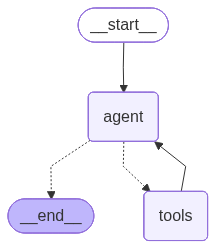

In [5]:
# 5. Build the Graph
builder = StateGraph(State)

# Add Nodes
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

# Add Flow (Edges)
builder.add_edge(START, "agent")


# The logic: If model calls a tool -> go to 'tools' node. 
# If model gives a final answer -> go to END.
builder.add_conditional_edges("agent", tools_condition)

# After tools are used, always go back to agent to summarize results
builder.add_edge("tools", "agent")

# Moves to the special END node to stop execution.
builder.add_edge("agent", END)

# Compile the Agent
agent = builder.compile()

#Converts the internal logic of your graph into a Mermaid-formatted PNG image so you can see the "map" of your agent.
graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [6]:
# 6. Run the Agent
if __name__ == "__main__":
    query = "Find top AI news from 2nd April 2026 to 5th April 2026."
    #query = "What is capital of France."
    
    print(" Agent is searching and summarizing...")
    inputs = {"messages": [HumanMessage(content=query)]}
    
    for chunk in agent.stream(inputs, stream_mode="values"):
        # Just print the last message for clean output
        last_msg = chunk["messages"][-1]
        if last_msg.content:
            last_msg.pretty_print()

 Agent is searching and summarizing...
================================ Human Message =================================

Find top AI news from 2nd April 2026 to 5th April 2026.
================================= Tool Message =================================
Name: tavily_search

{"query": "top AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.forbes.com/sites/sandycarter/2026/04/02/why-the-openai-tbpn-deal-today-is-bigger-than-anyone-is-saying/", "title": "Why The OpenAI TBPN Deal Today Is Bigger Than Anyone Is Saying - Forbes", "score": 0.9728308, "published_date": "Thu, 02 Apr 2026 22:18:26 GMT", "content": "AlignedNews.com\n\nBuilt by two people for roughly $10,000, the system monitors news across X and other platforms, writes its own coverage, generates a podcast through NotebookLM, distributes an email newsletter, and publishes an RSS feed, all with a built-in MCP server and OpenClaw feed. The infrastructure that once required lar